# Modelos computacionales y validación

En ciencias de la Tierra y geoquímica muchos procesos naturales se describen mediante **ecuaciones diferenciales**.  

Estas ecuaciones raramente tienen soluciones analíticas simples, por lo que es necesario resolverlas mediante **métodos numéricos**.

En este notebook estudiaremos un modelo simple de decaimiento químico y compararemos diferentes métodos numéricos para resolverlo.

El objetivo es:

- Implementar un modelo matemático
- Resolverlo con diferentes métodos numéricos
- Comparar las soluciones
- Analizar los errores del modelo

Este ejercicio ilustra cómo funcionan los **modelos computacionales** en ciencia.

## 1. Modelo de decaimiento químico

Consideremos una reacción simple:

A → productos

La velocidad de reacción es proporcional a la concentración de $A$:

$\frac{dC}{dt} = -kC$

donde

C = concentración  
k = constante de reacción

La solución analítica de esta ecuacion es:

$C(t) = C_0 e^{-kt}$

Esta solución nos permitirá **validar los métodos numéricos**.

In [18]:
# Datos de inicialización

import numpy as np
import matplotlib.pyplot as plt

k = 0.5      # constante de decaimiento del sistema
C0 = 1.0     # condición inicial de la concentración

t0 = 0       # tiempo inicial
tf = 10      # tiempo final
dt = 0.5     # paso de tiempo de la simulación

t = np.arange(t0, tf+dt, dt)  # vector de tiempo desde t0 hasta tf con incrementos dt

### Solucion analitica

En este caso vasta con implementar directamente la funcion de la ecuacion (1) y dar el valor exacto de la concentracion a medida que aumenta el tiempo. 

In [19]:
def analytic_solution(t, C0, k):
    # Calcula la solución analítica de la ecuación de decaimiento exponencial
    # C(t) = C0 * e^(-k t), donde:
    # C0 es la concentración inicial
    # k es la constante de decaimiento
    # t es el tiempo
    return C0*np.exp(-k*t)

C_exact = analytic_solution(t, C0, k)  # calcula los valores exactos de la concentración para cada tiempo en t

### Método de Euler

El método de Euler es el método numérico más simple para resolver ecuaciones diferenciales.

La ecuación diferencial a resolver es:

$$
\frac{dC}{dt} = -kC
$$

La derivada puede aproximarse mediante una diferencia finita:

$$
\frac{dC}{dt} \approx \frac{C_{i+1} - C_i}{\Delta t}
$$

Sustituyendo en la ecuación diferencial:

$$
\frac{C_{i+1} - C_i}{\Delta t} = -kC_i
$$

Despejando:

$$
C_{i+1} = C_i + \Delta t(-kC_i)
$$

Este método utiliza la **pendiente en el punto actual** para estimar el siguiente valor.

![Diagrama de modelo](Euler_method.svg.png)

### Interpretación geométrica

El método de Euler aproxima la solución mediante **segmentos de recta** usando la pendiente local.


### Ventajas

- simple de implementar
- rápido

### Desventajas

- errores relativamente grandes
- puede ser inestable para pasos de tiempo grandes

In [20]:
# Implementación del método de Euler

def euler_method(C0, k, t, dt):

    C = np.zeros(len(t))   # crea un arreglo para almacenar los valores de C en cada tiempo
    C[0] = C0              # asigna la condición inicial

    for i in range(len(t)-1):  # recorre todos los pasos de tiempo

        dCdt = -k*C[i]         # calcula la derivada dC/dt = -kC en el tiempo actual

        C[i+1] = C[i] + dt*dCdt  # actualiza el valor de C usando el método de Euler

    return C  # devuelve el vector con la solución numérica

C_euler = euler_method(C0, k, t, dt)  # calcula la solución usando el método de Euler

### Método Runge–Kutta de cuarto orden aplicado a este modelo

Recordemos que nuestro modelo es

$$
\frac{dC}{dt} = -kC
$$

Esto significa que la función de la ecuación diferencial es

$$
f(C,t) = -kC
$$

El método Runge–Kutta de cuarto orden (RK4) calcula varias estimaciones de la pendiente dentro del intervalo de tiempo $\Delta t$.

Primero se calcula una pendiente inicial:

$$
k_1 = f(C_i,t_i)
$$

Luego se calcula una pendiente en el punto medio usando $k_1$:

$$
k_2 = f\left(C_i + \frac{\Delta t}{2}k_1,\, t_i+\frac{\Delta t}{2}\right)
$$

Después se calcula otra pendiente en el punto medio usando $k_2$:

$$
k_3 = f\left(C_i + \frac{\Delta t}{2}k_2,\, t_i+\frac{\Delta t}{2}\right)
$$

Finalmente se calcula una pendiente al final del intervalo:

$$
k_4 = f(C_i + \Delta t k_3,\, t_i+\Delta t)
$$

---

### Aplicándolo a nuestra ecuación

Como

$$
f(C,t) = -kC
$$

las expresiones quedan:

$$
k_1 = -kC_i
$$

$$
k_2 = -k\left(C_i + \frac{\Delta t}{2}k_1\right)
$$

$$
k_3 = -k\left(C_i + \frac{\Delta t}{2}k_2\right)
$$

$$
k_4 = -k\left(C_i + \Delta t\,k_3\right)
$$

---

### Actualización de la solución

La concentración en el siguiente paso se calcula como

$$
C_{i+1} =
C_i +
\frac{\Delta t}{6}
\left(k_1 + 2k_2 + 2k_3 + k_4\right)
$$

---

### Interpretación

El método RK4 utiliza un **promedio ponderado de cuatro pendientes** dentro del intervalo de tiempo $\Delta t$.

Esto permite aproximar mucho mejor la solución real de la ecuación diferencial que el método de Euler, que solo usa una pendiente.

In [21]:
def rk4_method(C0, k, t, dt):

    C = np.zeros(len(t))   # arreglo para guardar los valores de C en cada tiempo
    C[0] = C0              # condición inicial

    for i in range(len(t)-1):  # recorre todos los pasos de tiempo

        k1 = -k*C[i]                 # primera pendiente evaluada en el punto actual
        k2 = -k*(C[i] + dt*k1/2)     # segunda pendiente evaluada en el punto medio usando k1
        k3 = -k*(C[i] + dt*k2/2)     # tercera pendiente nuevamente en el punto medio usando k2
        k4 = -k*(C[i] + dt*k3)       # cuarta pendiente evaluada al final del intervalo usando k3

        C[i+1] = C[i] + dt*(k1 + 2*k2 + 2*k3 + k4)/6  # actualización de C con RK4

    return C  # devuelve la solución numérica

C_rk4 = rk4_method(C0, k, t, dt)  # calcula la solución usando el método de Runge-Kutta de orden 4

### Comparacion de metodos

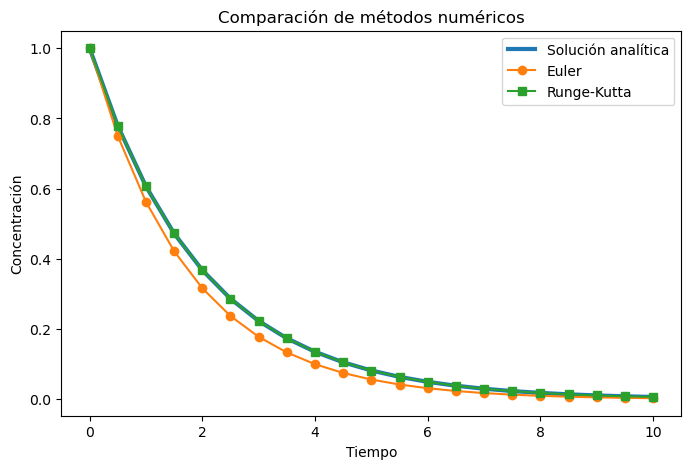

In [22]:
plt.figure(figsize=(8,5))  # crea una figura con tamaño específico

plt.plot(t, C_exact, label="Solución analítica", linewidth=3)  # grafica la solución exacta del modelo
plt.plot(t, C_euler, 'o-', label="Euler")  # grafica la solución aproximada usando el método de Euler
plt.plot(t, C_rk4, 's-', label="Runge-Kutta")  # grafica la solución aproximada usando Runge-Kutta de 4º orden

plt.xlabel("Tiempo")  # etiqueta del eje x
plt.ylabel("Concentración")  # etiqueta del eje y

plt.legend()  # muestra la leyenda de las curvas
plt.title("Comparación de métodos numéricos")  # título de la gráfica

plt.show()  # muestra la gráfica

### Error en los diferentes metodos y calculo de RMSE

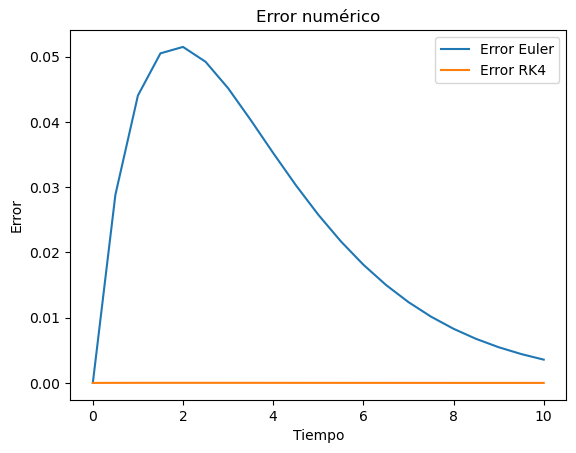

In [23]:
error_euler = np.abs(C_exact - C_euler)  # calcula el error absoluto entre la solución analítica y la de Euler
error_rk4 = np.abs(C_exact - C_rk4)      # calcula el error absoluto entre la solución analítica y la de Runge-Kutta

plt.plot(t, error_euler, label="Error Euler")  # grafica el error del método de Euler en función del tiempo
plt.plot(t, error_rk4, label="Error RK4")      # grafica el error del método Runge-Kutta

plt.xlabel("Tiempo")   # etiqueta del eje x
plt.ylabel("Error")    # etiqueta del eje y

plt.legend()  # muestra la leyenda para distinguir los errores
plt.title("Error numérico")  # título de la gráfica

plt.show()  # muestra la gráfica

In [24]:
def rmse(y_true, y_model):
    # Calcula el error cuadrático medio (Root Mean Square Error)
    # Mide qué tan diferente es el modelo respecto a la solución real
    return np.sqrt(np.mean((y_true-y_model)**2))

print("RMSE Euler =", rmse(C_exact, C_euler))  # error promedio del método de Euler
print("RMSE RK4 =", rmse(C_exact, C_rk4))      # error promedio del método Runge-Kutta

RMSE Euler = 0.02954447911959464
RMSE RK4 = 8.743415005389709e-06


## Preguntas

1. ¿Cuál método reproduce mejor la solución analítica?

2. ¿Qué ocurre si aumentamos el paso temporal $\Delta t$?

3. ¿Por qué el método de Euler presenta mayor error?

4. ¿Qué implicaciones tiene esto para modelos geoquímicos complejos?

5. ¿Por qué es importante validar los modelos computacionales?

## Problema 1. Ejercicio de análisis numérico

En el modelo implementado anteriormente, el paso temporal $\Delta t$ controla la resolución temporal del método numérico.

1. Modifique el valor del paso temporal en el código y ejecute nuevamente las simulaciones para los siguientes valores:

$$
\Delta t = 2
$$

$$
\Delta t = 1
$$

$$
\Delta t = 0.1
$$

2. Para cada valor de $\Delta t$:

- Grafique la solución obtenida con los métodos de **Euler** y **Runge–Kutta (RK4)**.
- Compare cada solución con la **solución analítica**.

3. Calcule el **error cuadrático medio (RMSE)** para cada método y cada valor de $\Delta t$.

4. Con base en los resultados obtenidos, responda:

a) ¿Cómo cambia el error numérico cuando el paso temporal $\Delta t$ aumenta o disminuye?

b) ¿Cuál de los dos métodos muestra mayor estabilidad y precisión?

c) ¿Qué implicaciones tiene el tamaño del paso temporal en la construcción de modelos computacionales para sistemas geoquímicos?

## Problema 2: Disolución de calcita en sistemas acuosos

La calcita ($CaCO_3$) es uno de los minerales más abundantes en sistemas naturales y juega un papel fundamental en la geoquímica del carbono, en la química de aguas naturales y en procesos de meteorización.

La disolución de calcita ocurre cuando el mineral entra en contacto con agua que no está en equilibrio con el carbonato de calcio. Este proceso es especialmente importante en ambientes donde el agua contiene dióxido de carbono disuelto o presenta valores de pH relativamente bajos.

---

### Reacción de disolución

La reacción global de disolución de calcita en presencia de protones puede escribirse como

$$
CaCO_3(s) + H^+ \rightarrow Ca^{2+} + HCO_3^-
$$

En esta reacción:

- el mineral sólido libera calcio al agua
- el carbonato se transforma en bicarbonato
- los protones favorecen la disolución del mineral

Por esta razón, la velocidad de disolución de calcita depende fuertemente del **pH del sistema**.

---

### Cinética de disolución

La velocidad de disolución de minerales suele describirse mediante leyes cinéticas que dependen de la distancia al equilibrio químico.

Una forma simplificada de la ley cinética para calcita es

$$
\frac{dC}{dt} = k_H [H^+] (1-\Omega)
$$

donde

- $r$ es la velocidad de reacción
- $k_H$ es una constante cinética
- $[H^+]$ es la concentración de protones
- $\Omega$ es el índice de saturación del mineral

---

### Índice de saturación

El índice de saturación mide qué tan lejos está la solución del equilibrio con el mineral.

Se define como

$$
\Omega = \frac{IAP}{K_{sp}}
$$

donde

- $IAP$ es el **producto iónico**
- $K_{sp}$ es la **constante de solubilidad del mineral**

El comportamiento del sistema depende de $\Omega$:

| Condición | Significado |
|-----------|-------------|
| $\Omega < 1$ | el mineral se disuelve |
| $\Omega = 1$ | equilibrio químico |
| $\Omega > 1$ | el mineral precipita |

---

### Aproximación simplificada

Para simplificar el problema, supondremos que el índice de saturación depende únicamente de la concentración de calcio en solución:

$$
\Omega = \frac{C}{C_{eq}}
$$

donde

- $C$ es la concentración de calcio en solución
- $C_{eq}$ es la concentración de equilibrio.

Sustituyendo esta expresión en la ley cinética obtenemos

$$
\frac{dC}{dt} =
k_H [H^+] \left(1-\frac{C}{C_{eq}}\right)
$$

---

### Relación entre pH y concentración de protones

La concentración de protones está relacionada con el pH mediante

$$
[H^+] = 10^{-pH}
$$

Por lo tanto, el modelo final se puede escribir como

$$
\frac{dC}{dt} =
k_H 10^{-pH}
\left(1-\frac{C}{C_{eq}}\right)
$$

---

### Interpretación física del modelo

Este modelo describe tres comportamientos importantes:

1. **Dependencia del pH**

A pH bajos la concentración de protones es mayor y la disolución ocurre más rápidamente.

2. **Efecto del equilibrio**

A medida que la concentración de calcio aumenta, el sistema se aproxima al equilibrio químico y la velocidad de reacción disminuye.

3. **Estado final del sistema**

Cuando

$$
C \rightarrow C_{eq}
$$

la velocidad de disolución tiende a cero y el sistema alcanza el equilibrio.

---

### Objetivo del modelo computacional

En este ejercicio utilizaremos métodos numéricos para resolver la ecuación diferencial que describe la evolución temporal de la concentración de calcio durante la disolución de calcita.

## Problema 2: Disolución de calcita dependiente del pH

La disolución de calcita puede describirse mediante el modelo

$$
\frac{dC}{dt} =
k_H 10^{-pH}
\left(1-\frac{C}{C_{eq}}\right)
$$

donde

- $C$ es la concentración de calcio en solución
- $k_H$ es una constante cinética
- $C_{eq}$ es la concentración de equilibrio

---

### Parámetros

$$
k_H = 5\times10^3
$$

$$
C_{eq} = 2\times10^{-3}
$$

$$
C(0)=0
$$

---

### Actividades

1. Implemente el modelo usando

- método de Euler
- método Runge–Kutta de cuarto orden

2. Simule la evolución de $C(t)$ para

- $pH = 5$
- $pH = 6$
- $pH = 7$

3. Grafique los resultados.

4. Compare las curvas obtenidas y responda:

a) ¿Cómo afecta el pH la velocidad de disolución de calcita?

b) ¿Por qué la disolución es más rápida a pH bajos?

c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?

5. Analice el efecto del paso temporal $\Delta t$ en la estabilidad del modelo.

In [25]:
import numpy as np
import matplotlib.pyplot as plt

kH = 5e3      # constante de transferencia o coeficiente cinético del proceso
Ceq = 2e-3    # concentración de equilibrio (estado al que el sistema tiende)

C0 = 0        # concentración inicial del sistema

In [26]:
def dCdt(C, pH):

    rate = kH * 10**(-pH)  # calcula la tasa de reacción dependiente del pH

    # ecuación diferencial: la velocidad disminuye a medida que C se acerca al equilibrio Ceq
    return rate * (1 - C/Ceq)

In [27]:
def euler_step(C, dt, pH):

    # aplica un paso del método de Euler para actualizar la concentración
    # C_n+1 = C_n + dt * dC/dt
    return C + dt*dCdt(C,pH)

In [28]:
def rk4_step(C, dt, pH):

    k1 = dCdt(C,pH)  # primera pendiente evaluada en el punto actual

    k2 = dCdt(C + 0.5*dt*k1, pH)  # segunda pendiente evaluada en el punto medio usando k1

    k3 = dCdt(C + 0.5*dt*k2, pH)  # tercera pendiente evaluada nuevamente en el punto medio usando k2

    k4 = dCdt(C + dt*k3, pH)  # cuarta pendiente evaluada al final del intervalo usando k3

    return C + dt*(k1 + 2*k2 + 2*k3 + k4)/6  # actualización de C usando Runge-Kutta de cuarto orden

In [29]:
dt = 0.01        # tamaño del paso de tiempo para la integración numérica
tmax = 5         # tiempo máximo de la simulación

steps = int(tmax/dt)  # número total de pasos de tiempo

time = np.linspace(0,tmax,steps)  # vector de tiempo desde 0 hasta tmax

pH_values = [5,6,7]  # lista de valores de pH que se evaluarán en la simulación

In [30]:
results_euler = {}  # diccionario para almacenar los resultados del método de Euler para cada valor de pH

for pH in pH_values:  # recorre cada valor de pH definido

    C = C0            # reinicia la concentración con la condición inicial
    C_values = []     # lista para guardar la evolución de la concentración

    for i in range(steps):  # recorre todos los pasos de tiempo

        C = euler_step(C,dt,pH)  # actualiza la concentración usando un paso del método de Euler

        C_values.append(C)       # guarda el valor actualizado de C

    results_euler[pH] = np.array(C_values)  # almacena los resultados en el diccionario como arreglo

In [31]:
results_rk4 = {}  # diccionario para almacenar los resultados del método Runge-Kutta para cada pH

for pH in pH_values:  # recorre cada valor de pH

    C = C0            # reinicia la concentración con la condición inicial
    C_values = []     # lista para guardar la evolución de la concentración

    for i in range(steps):  # recorre todos los pasos de tiempo

        C = rk4_step(C,dt,pH)  # actualiza la concentración usando un paso del método RK4

        C_values.append(C)     # guarda el valor actualizado de C

    results_rk4[pH] = np.array(C_values)  # almacena los resultados en el diccionario como arreglo

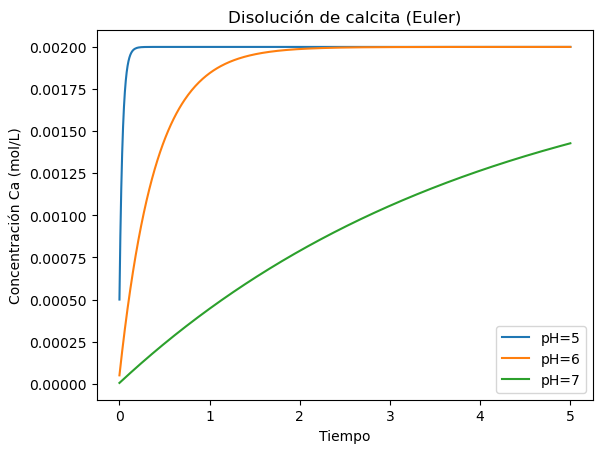

In [32]:
plt.figure()  # crea una nueva figura para la gráfica

for pH in pH_values:  # recorre cada valor de pH

    plt.plot(time, results_euler[pH], label=f"pH={pH}")  # grafica la concentración de Ca para cada pH usando Euler

plt.xlabel("Tiempo")  # etiqueta del eje x
plt.ylabel("Concentración Ca (mol/L)")  # etiqueta del eje y
plt.title("Disolución de calcita (Euler)")  # título de la gráfica

plt.legend()  # muestra la leyenda con los valores de pH
plt.show()  # muestra la gráfica

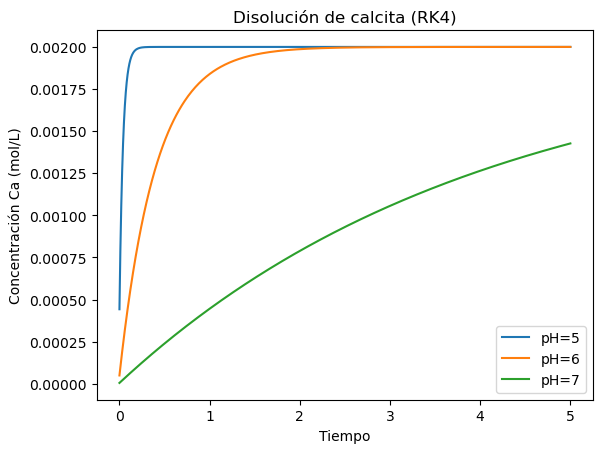

In [16]:
plt.figure()

for pH in pH_values:

    plt.plot(time, results_rk4[pH], label=f"pH={pH}")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca (mol/L)")
plt.title("Disolución de calcita (RK4)")

plt.legend()
plt.show()

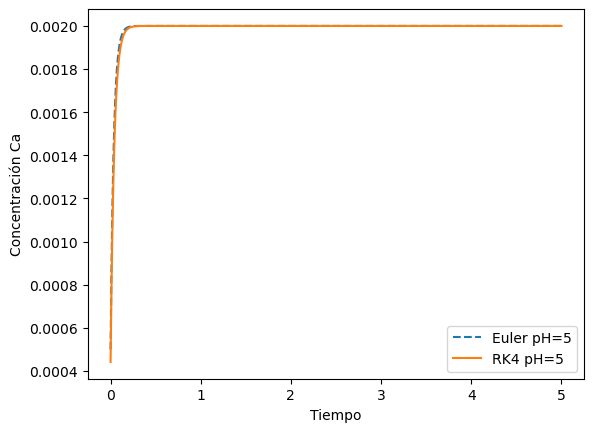

In [17]:
plt.figure()

plt.plot(time, results_euler[5], '--', label="Euler pH=5")
plt.plot(time, results_rk4[5], label="RK4 pH=5")

plt.xlabel("Tiempo")
plt.ylabel("Concentración Ca")

plt.legend()
plt.show()

## Respuestas conceptuales

### a) ¿Cómo afecta el pH la velocidad de disolución de calcita?

La velocidad de disolución depende del término

$$
10^{-pH}
$$

lo cual representa la concentración de protones $H^+$ en solución.

Esto implica que:

- A **pH bajos** (medio más ácido) la concentración de $H^+$ es mayor.
- A **pH altos** (medio más básico) la concentración de $H^+$ es menor.

Por lo tanto, la velocidad de disolución de calcita es **mayor a pH bajos** y **menor a pH altos**. En las simulaciones se observa que la concentración de calcio aumenta más rápidamente cuando el pH es menor.

---

### b) ¿Por qué la disolución es más rápida a pH bajos?

La disolución de calcita está controlada por reacciones con protones. Una reacción simplificada es:

$$
CaCO_3 + H^+ \rightarrow Ca^{2+} + HCO_3^-
$$

En medios ácidos hay una mayor concentración de $H^+$, lo que favorece esta reacción. Los protones atacan la superficie del mineral y facilitan la liberación de calcio al agua. Por esta razón, la disolución de calcita ocurre más rápidamente cuando el pH es bajo.

---

### c) ¿Qué ocurre cuando $C$ se aproxima a $C_{eq}$?

En el modelo, la velocidad de reacción depende del factor

$$
\left(1-\frac{C}{C_{eq}}\right)
$$

Cuando la concentración en solución se aproxima al valor de equilibrio $C_{eq}$, este término tiende a cero:

$$
\frac{dC}{dt} \rightarrow 0
$$

Esto significa que la velocidad de disolución disminuye progresivamente y el sistema se aproxima al **equilibrio químico**. En ese punto ya no hay disolución neta de calcita.

---

### d) ¿Cómo afecta el paso temporal $\Delta t$ a la estabilidad del modelo?

El paso temporal controla la resolución numérica del modelo.

- Si $\Delta t$ es **pequeño**, la solución es más precisa y estable.
- Si $\Delta t$ es **muy grande**, el método de Euler puede producir errores importantes o incluso volverse inestable.

El método de **Runge–Kutta de cuarto orden (RK4)** es más preciso y estable que el método de Euler para un mismo paso temporal, porque evalúa la pendiente varias veces dentro de cada intervalo de tiempo.

Por esta razón, RK4 suele proporcionar resultados más confiables en simulaciones numéricas de procesos geoquímicos.